### Importing the necessary Libraries 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import hedging as hedge
import mistmatched

### Setting Initial Parameters

In [ ]:
S0 = 100
K = 99
r = 0.06
T = 1
sigma = 0.20

### Running Hedging Simulation over different Hedging Frequencies 

In [21]:
hedge_frequencies = [1, 5, 21]
results = {}
for freq in hedge_frequencies:
    freq_name = {1: "Daily", 5: "Weekly", 21: "Monthly"}[freq]
    results[freq_name] = hedge.run_hedging_simulation(S0, K, r, sigma, T, freq)

In [14]:
summary = hedge.create_summary_statistics(results)

In [15]:
print("Summary Statistics for Hedging Simulation:")
print(summary)

Summary Statistics for Hedging Simulation:
  Hedging Frequency  Mean PnL  Std Dev PnL    Min PnL   Max PnL
0             Daily -0.004348     0.425999  -2.606533  2.128786
1            Weekly  0.013879     0.931517  -5.152315  4.226084
2           Monthly  0.009909     1.903053 -11.902094  6.364512


### Plots

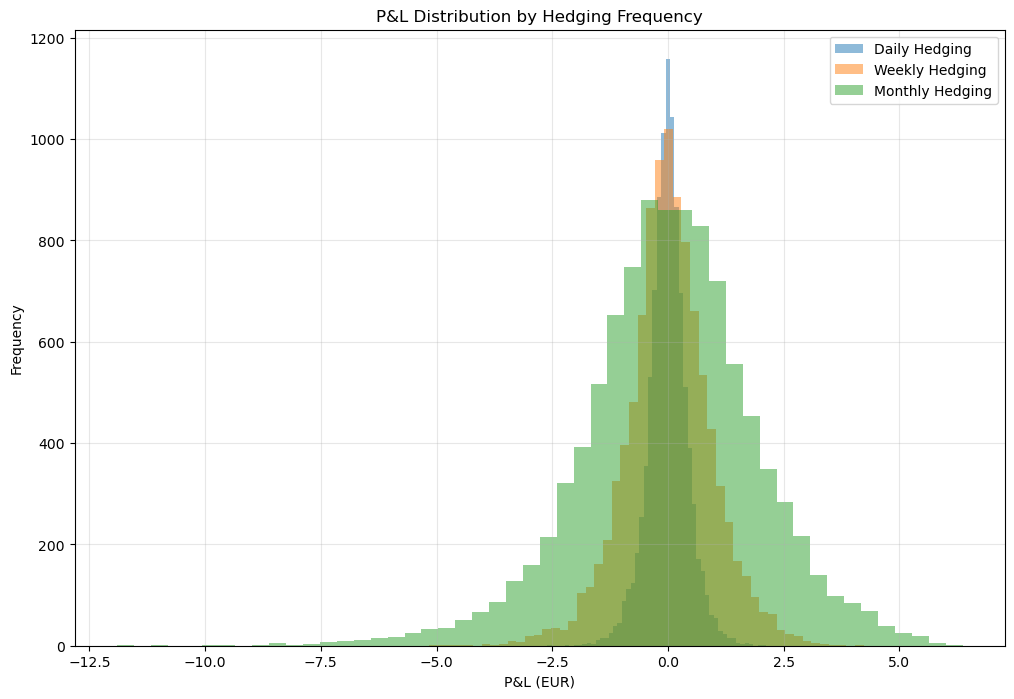

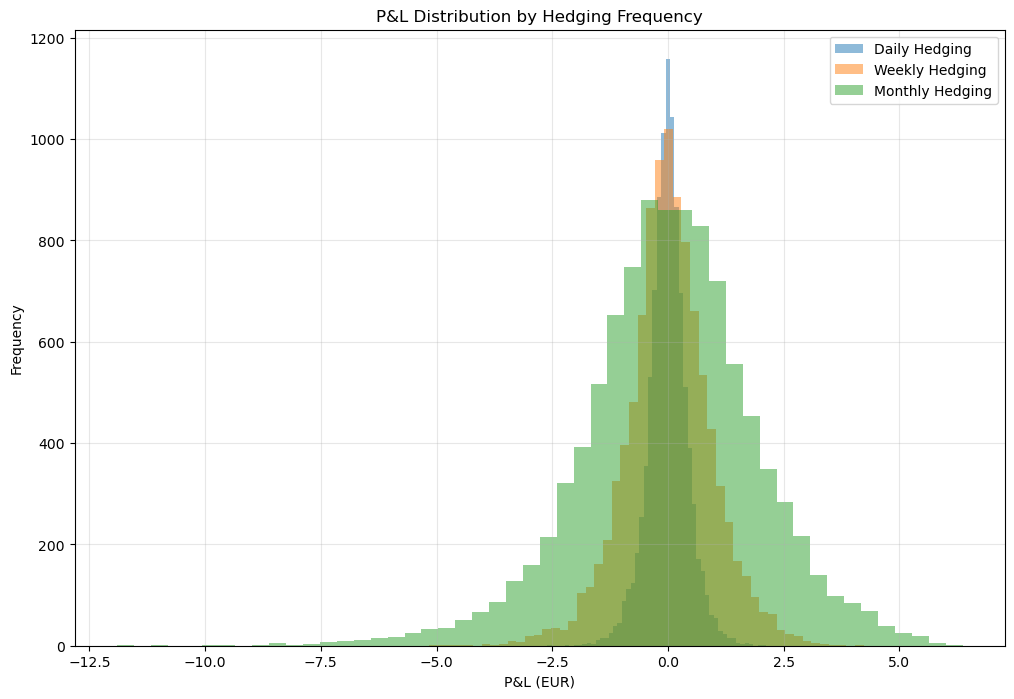

In [18]:
hedge.plot_histogram_distribution(results)

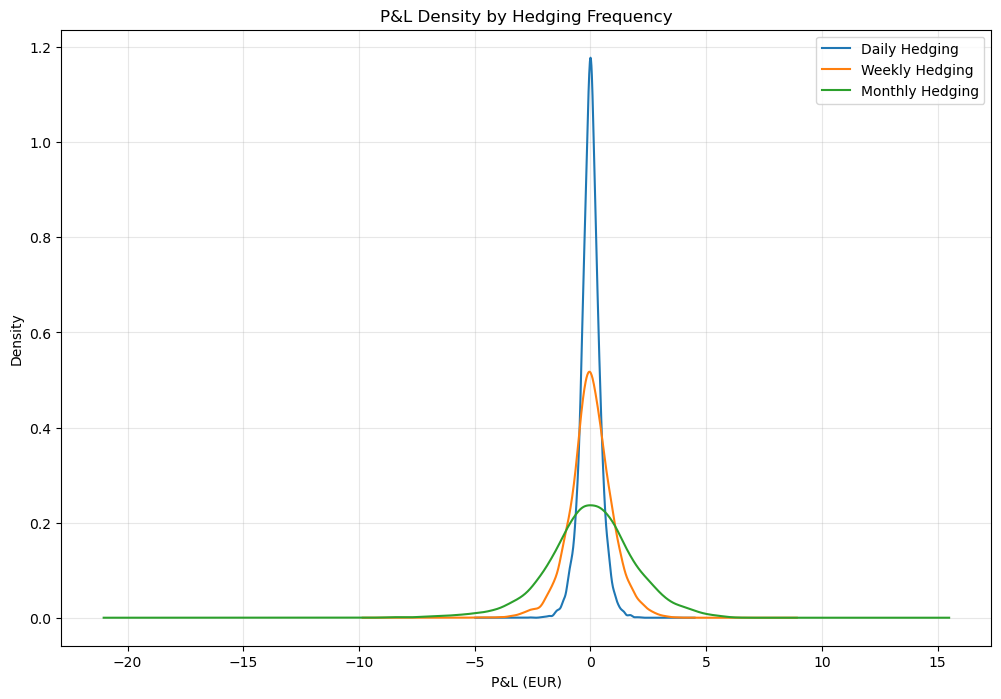

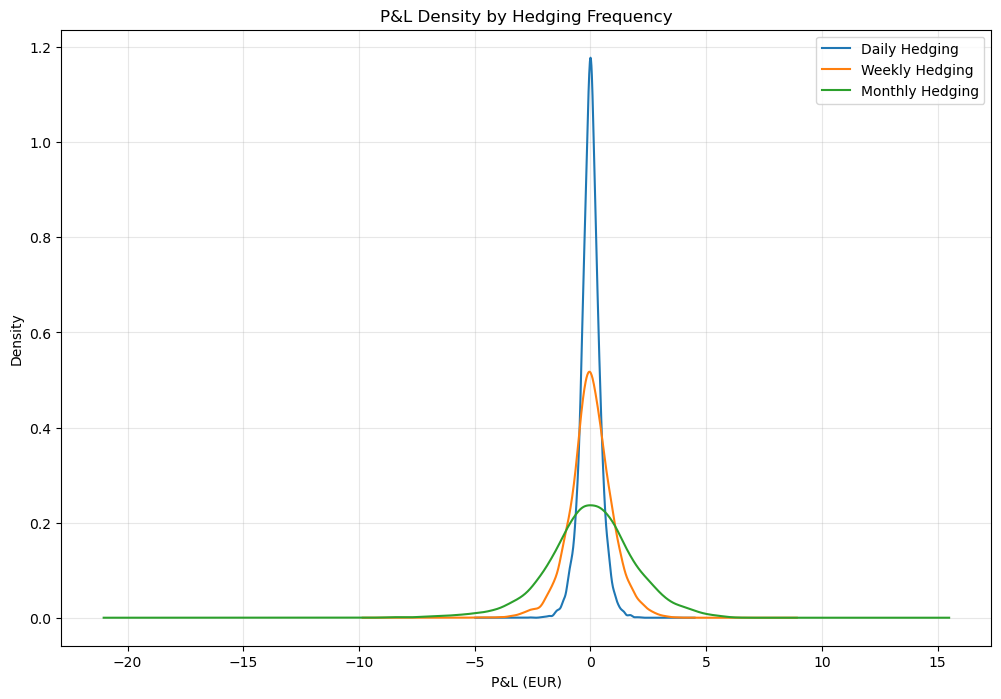

In [16]:
hedge.plot_density_curves(results)

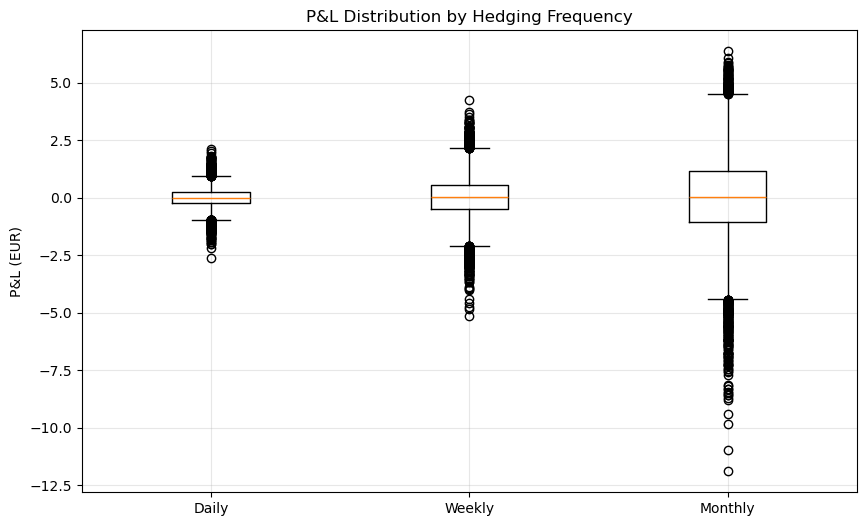

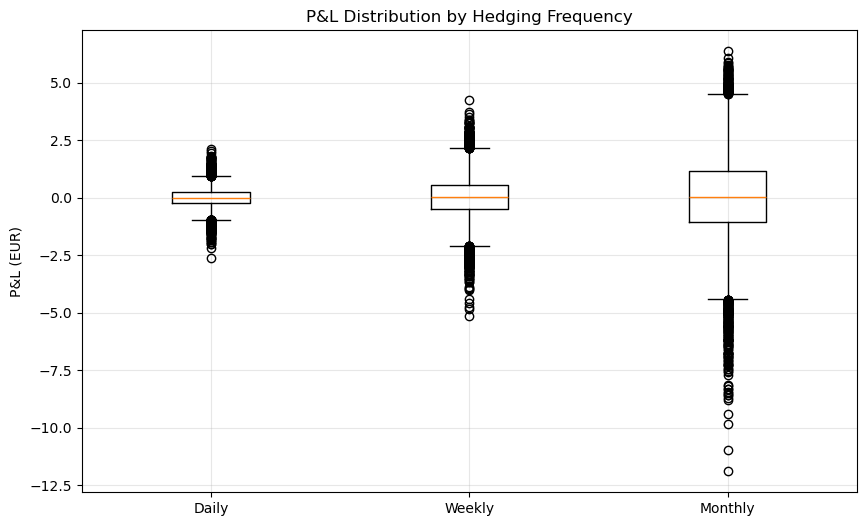

In [20]:
hedge.plot_boxplot_comparison(results)

In [4]:
market_volatilities=[0.10, 0.15, 0.20, 0.25, 0.30] # Set the different values of Market Volatility

### Run experiment for Daily Hedging

In [5]:
results_daily = mistmatched.run_hedging_scenarios(S0, K, r, T, sigma, market_volatilities, hedge_frequency=1)
summary_daily = mistmatched.create_summary_statistics(results_daily)
print("Summary Statistics for Mismatched Volatility Simulation (Daily Hedging):")
print(summary_daily)

Summary Statistics for Mismatched Volatility Simulation (Daily Hedging):
                          Scenario  Mean PnL  Std Dev PnL    Min PnL   Max PnL
0  Market Vol 10% vs Model Vol 20%  3.610215     1.112393   0.693690  6.221744
1  Market Vol 15% vs Model Vol 20%  1.878007     0.739006   0.174580  4.418571
2  Market Vol 20% vs Model Vol 20% -0.004348     0.425999  -2.606533  2.128786
3  Market Vol 25% vs Model Vol 20% -1.942250     1.005278  -6.828679 -0.007603
4  Market Vol 30% vs Model Vol 20% -3.906355     1.938633 -11.407026 -0.328564


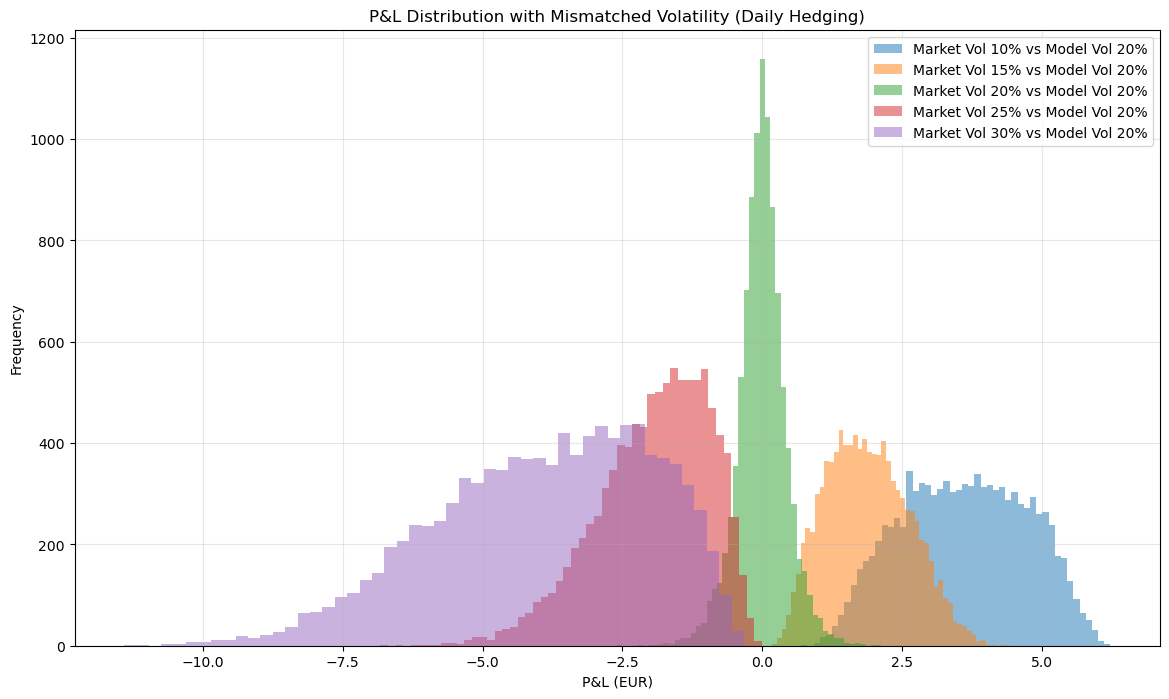

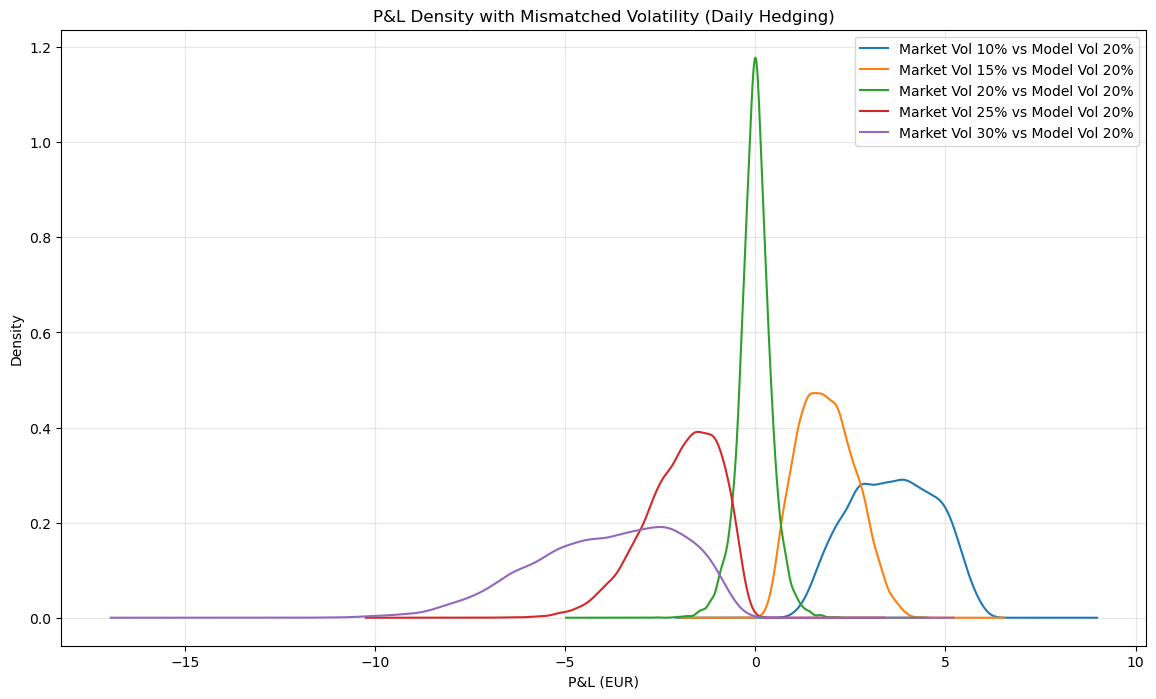

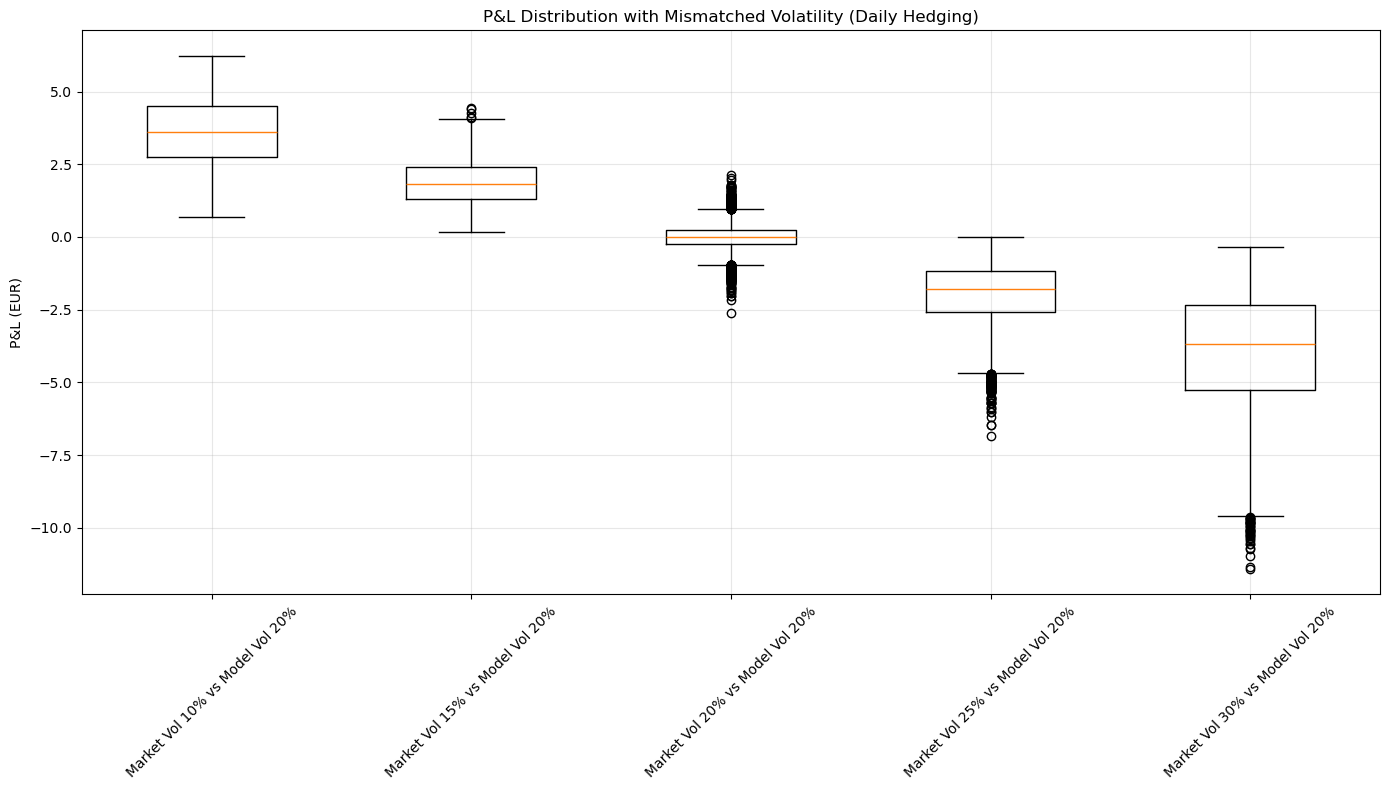

In [6]:
mistmatched.plot_histograms(results_daily, 'P&L Distribution with Mismatched Volatility (Daily Hedging)')
mistmatched.plot_density(results_daily, 'P&L Density with Mismatched Volatility (Daily Hedging)')
mistmatched.plot_boxplots(results_daily, 'P&L Distribution with Mismatched Volatility (Daily Hedging)')

### Run simulation for Weekly Hedging

In [8]:
results_weekly = mistmatched.run_hedging_scenarios(S0, K, r, T, sigma, market_volatilities, hedge_frequency=5)
summary_weekly = mistmatched.create_summary_statistics(results_weekly)
print("\nSummary Statistics for Mismatched Volatility Simulation (Weekly Hedging):")
print(summary_weekly)


Summary Statistics for Mismatched Volatility Simulation (Weekly Hedging):
                          Scenario  Mean PnL  Std Dev PnL    Min PnL   Max PnL
0  Market Vol 10% vs Model Vol 20%  3.614408     1.178493   0.477458  6.820341
1  Market Vol 15% vs Model Vol 20%  1.887595     0.963934  -1.044087  5.641031
2  Market Vol 20% vs Model Vol 20%  0.013879     0.931517  -5.152315  4.226084
3  Market Vol 25% vs Model Vol 20% -1.916906     1.430857 -10.028914  2.570903
4  Market Vol 30% vs Model Vol 20% -3.877199     2.283072 -16.423189  0.653412


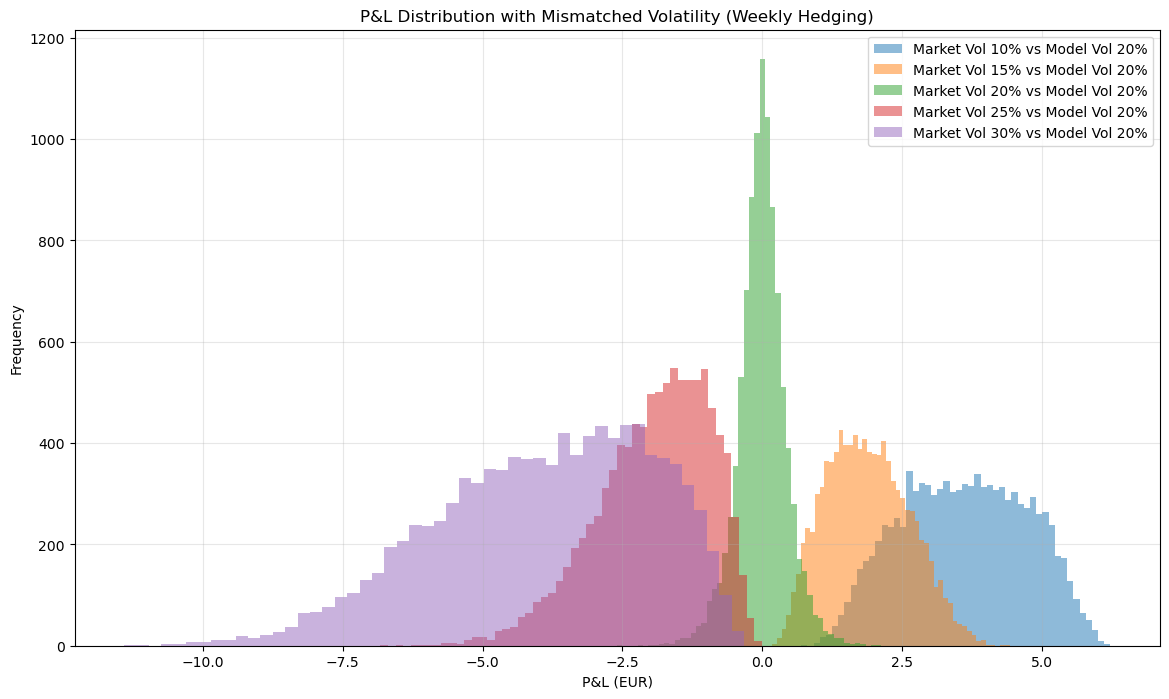

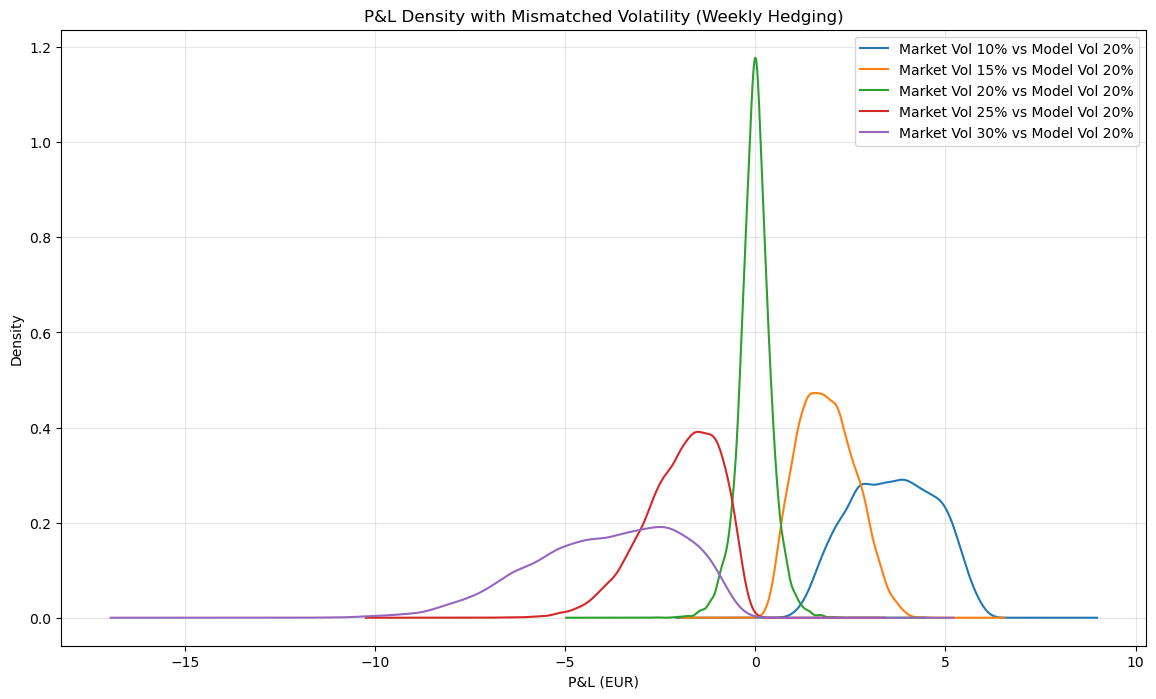

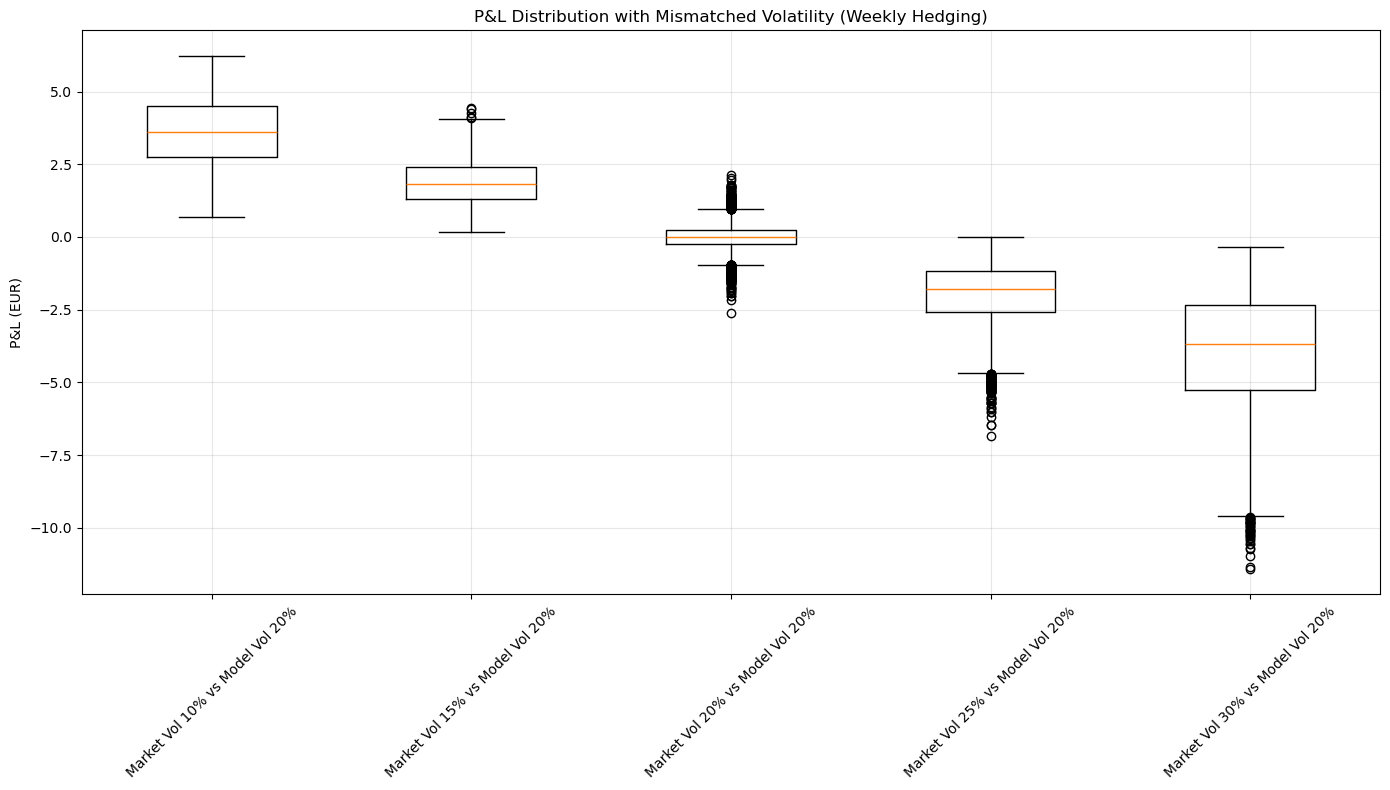

In [9]:
mistmatched.plot_histograms(results_daily, 'P&L Distribution with Mismatched Volatility (Weekly Hedging)')
mistmatched.plot_density(results_daily, 'P&L Density with Mismatched Volatility (Weekly Hedging)')
mistmatched.plot_boxplots(results_daily, 'P&L Distribution with Mismatched Volatility (Weekly Hedging)')

In [10]:
vol_values = [float(s.split('%')[0].split()[-1])/100 for s in results_daily.keys()]
mean_pnl_daily = [results_daily[k]['PnL'].mean() for k in results_daily]
mean_pnl_weekly = [results_weekly[k]['PnL'].mean() for k in results_weekly]
std_pnl_daily = [results_daily[k]['PnL'].std() for k in results_daily]
std_pnl_weekly = [results_weekly[k]['PnL'].std() for k in results_weekly]

### Comparison between P&L Mean and Standard Deviation for Daily vs Weekly Hedging

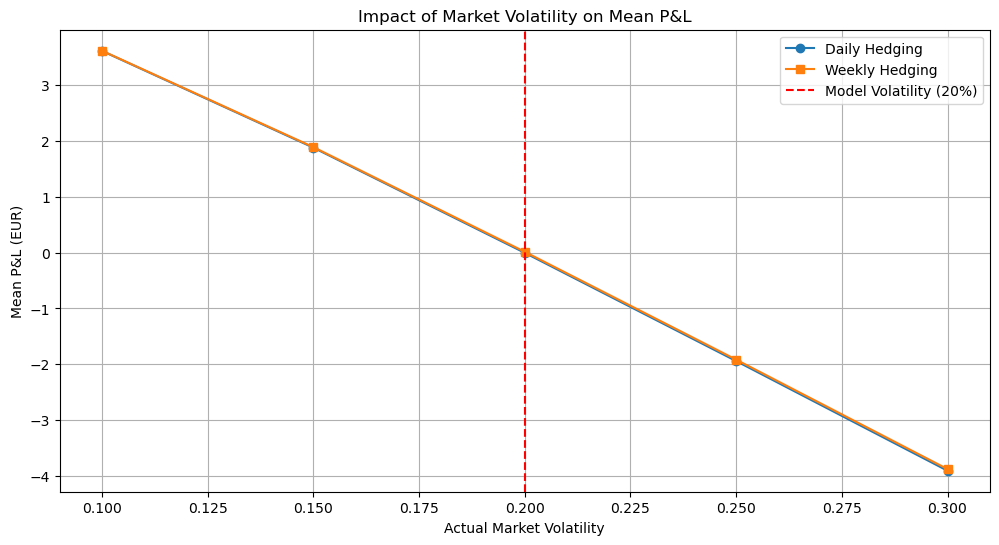

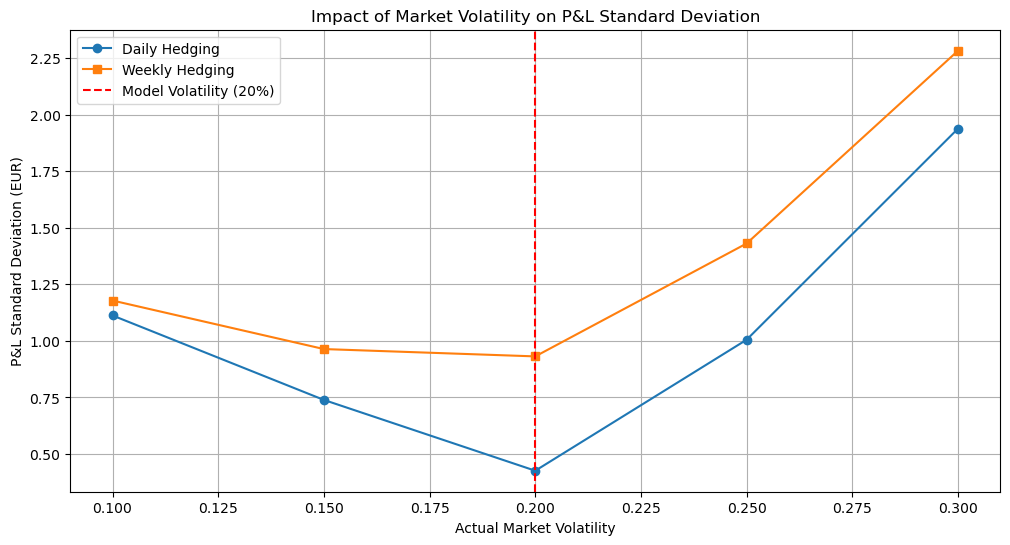

In [11]:
mistmatched.plot_mean_std_vs_volatility(vol_values, mean_pnl_daily, mean_pnl_weekly, std_pnl_daily, std_pnl_weekly, sigma)

In [12]:
comparison = pd.DataFrame({
    'Market Volatility': [f"{vol*100:.0f}%" for vol in market_volatilities],
    'Daily Mean P&L': mean_pnl_daily,
    'Daily Std Dev': std_pnl_daily,
    'Weekly Mean P&L': mean_pnl_weekly,
    'Weekly Std Dev': std_pnl_weekly
})

print("\nComparison of P&L Statistics by Market Volatility:")
print(comparison)


Comparison of P&L Statistics by Market Volatility:
  Market Volatility  Daily Mean P&L  Daily Std Dev  Weekly Mean P&L  \
0               10%        3.610215       1.112393         3.614408   
1               15%        1.878007       0.739006         1.887595   
2               20%       -0.004348       0.425999         0.013879   
3               25%       -1.942250       1.005278        -1.916906   
4               30%       -3.906355       1.938633        -3.877199   

   Weekly Std Dev  
0        1.178493  
1        0.963934  
2        0.931517  
3        1.430857  
4        2.283072  
